# Learning Curves

Plots evaluation metrics across `fraction_labeled` for MAE and/or I-JEPA.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.chdir(os.path.join(os.getcwd(), '..'))

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'font.size': 11,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.minor.visible': False,
    'ytick.minor.visible': False,
    'axes.grid': False,
    'lines.linewidth': 1.4,
})

## Configuration

In [ ]:
OUTPUTS_DIR = "outputs"

# Select model: "mae" or "ijepa"
MODEL = "mae"
DATASET = "ucm_mlc"

# Auto-build experiments from model selection
_EXP_NAME = f"{MODEL}_{DATASET}"
EXPERIMENTS = {
    "Semi-Supervised":     {"name": _EXP_NAME, "mode": "semi_supervised",     "color": "#2176AE", "marker": "o"},
    "Supervised":          {"name": _EXP_NAME, "mode": "supervised",          "color": "#E8871E", "marker": "s"},
    "Supervised Baseline": {"name": _EXP_NAME, "mode": "supervised_baseline", "color": "#57A773", "marker": "^"},
}

FRACTIONS = [0.01, 0.05, 0.1, 0.25]

METRICS_TO_PLOT = [
    {"key": "average auprc",   "title": r"Average AUPRC"},
    {"key": "ranking loss",    "title": r"Ranking Loss"},
    {"key": "micro f1",        "title": r"Micro $F_1$"},
    {"key": "subset accuracy", "title": r"Subset Accuracy"},
]

## Load results

In [3]:
def load_results(exp_name, mode, fraction, outputs_dir=OUTPUTS_DIR, max_versions=5):
    """Load metrics.txt for a given experiment."""
    results = []
    base = os.path.join(outputs_dir, exp_name, mode, f"fl_{fraction}")

    p = os.path.join(base, "results", "metrics.txt")
    if os.path.exists(p):
        results.append(pd.read_csv(p, sep="\t", index_col=0))

    for v in range(max_versions):
        p = os.path.join(base, f"results_v{v}", "metrics.txt")
        if os.path.exists(p):
            results.append(pd.read_csv(p, sep="\t", index_col=0))
    return results


def collect_metric(exp_name, mode, fractions, metric_key):
    """Collect a metric across fractions. Returns means and stds."""
    means, stds = [], []
    for frac in fractions:
        dfs = load_results(exp_name, mode, frac)
        vals = [df.loc[metric_key, "Metric Value"] for df in dfs if metric_key in df.index]
        if vals:
            means.append(np.mean(vals))
            stds.append(np.std(vals) if len(vals) > 1 else 0.0)
        else:
            means.append(np.nan)
            stds.append(0.0)
    return np.array(means), np.array(stds)

## Plot

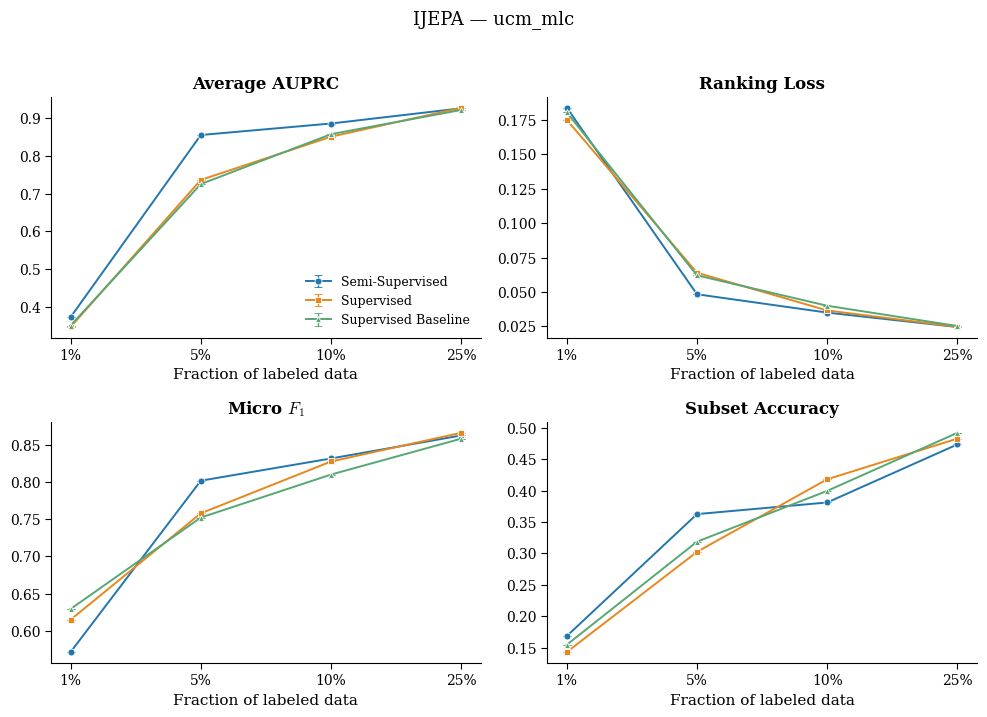

In [4]:
n_metrics = len(METRICS_TO_PLOT)
n_cols = min(2, n_metrics)
n_rows = int(np.ceil(n_metrics / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = np.atleast_2d(axes).flatten()

x_pos = np.arange(len(FRACTIONS))
x_labels = [f"{int(f * 100)}%" for f in FRACTIONS]

for ax_idx, m in enumerate(METRICS_TO_PLOT):
    ax = axes[ax_idx]
    for label, cfg in EXPERIMENTS.items():
        means, stds = collect_metric(cfg["name"], cfg["mode"], FRACTIONS, m["key"])
        valid = ~np.isnan(means)
        if not valid.any():
            continue
        ax.errorbar(
            x_pos[valid], means[valid], yerr=stds[valid],
            label=label, color=cfg["color"],
            marker=cfg["marker"], markersize=5, capsize=3,
            capthick=1, elinewidth=1,
            markeredgecolor="white", markeredgewidth=0.6,
        )
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels)
    ax.set_xlabel(r"Fraction of labeled data")
    ax.set_title(m["title"])
    if ax_idx == 0:
        ax.legend(frameon=True, edgecolor="none", facecolor="white")

for idx in range(n_metrics, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle(f"{MODEL.upper()} — {DATASET}", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Results Table

In [5]:
rows = []
for label, cfg in EXPERIMENTS.items():
    for frac in FRACTIONS:
        dfs = load_results(cfg["name"], cfg["mode"], frac)
        if dfs:
            df = dfs[0]
            row = {"Method": label, "Fraction": f"{int(frac*100)}%"}
            for m in METRICS_TO_PLOT:
                if m["key"] in df.index:
                    row[m["key"]] = f"{df.loc[m['key'], 'Metric Value']:.4f}"
            rows.append(row)

if rows:
    summary = pd.DataFrame(rows).set_index(["Method", "Fraction"])
    display(summary)
else:
    print("No results found.")

average auprc ranking loss micro f1  \
Method              Fraction                                       
Semi-Supervised     1%              0.3724       0.1839   0.5713   
                    5%              0.8557       0.0484   0.8017   
                    10%             0.8862       0.0351   0.8315   
                    25%             0.9266       0.0246   0.8625   
Supervised          1%              0.3462       0.1752   0.6147   
                    5%              0.7365       0.0641   0.7578   
                    10%             0.8512       0.0366   0.8275   
                    25%             0.9280       0.0247   0.8661   
Supervised Baseline 1%              0.3502       0.1806   0.6292   
                    5%              0.7255       0.0622   0.7521   
                    10%             0.8579       0.0401   0.8099   
                    25%             0.9223       0.0253   0.8582   

                             subset accuracy  
Method              Fraction                  
Semi-Supervised     1%                0.1686  
                    5%                0.3626  
                    10%               0.3811  
                    25%               0.4734  
Supervised          1%                0.1432  
                    5%                0.3025  
                    10%               0.4180  
                    25%               0.4827  
Supervised Baseline 1%                0.1547  
                    5%                0.3187  
                    10%               0.3995  
                    25%               0.4919

## Grouped Bar Plots

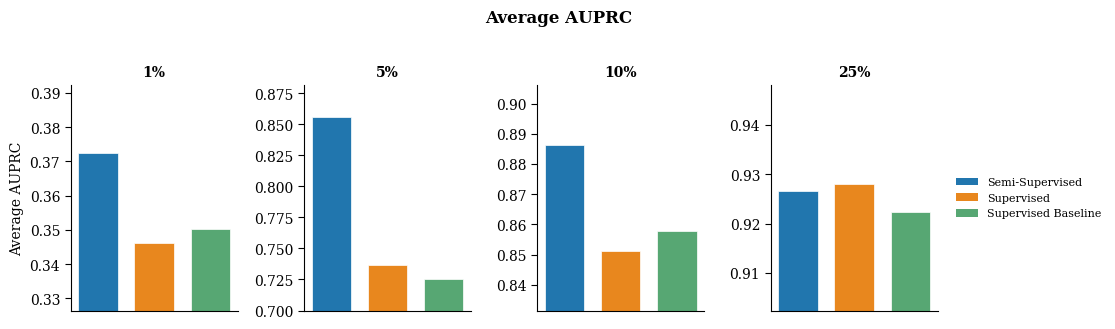

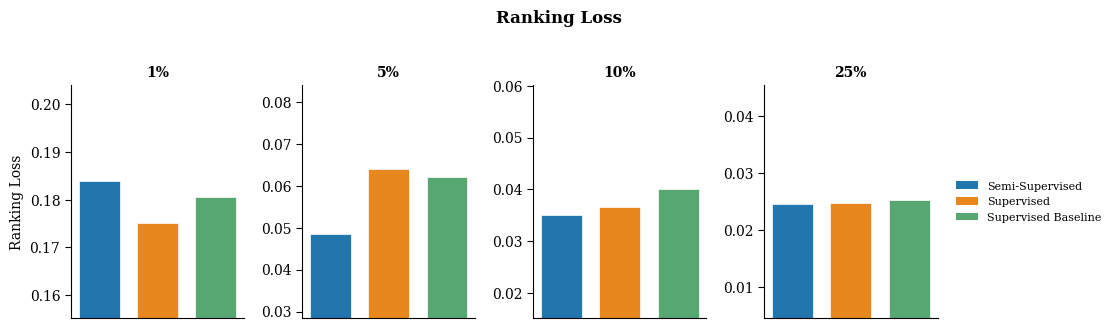

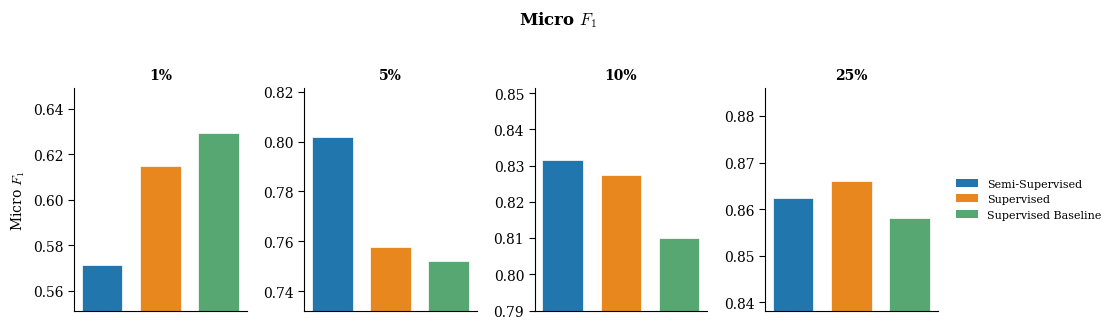

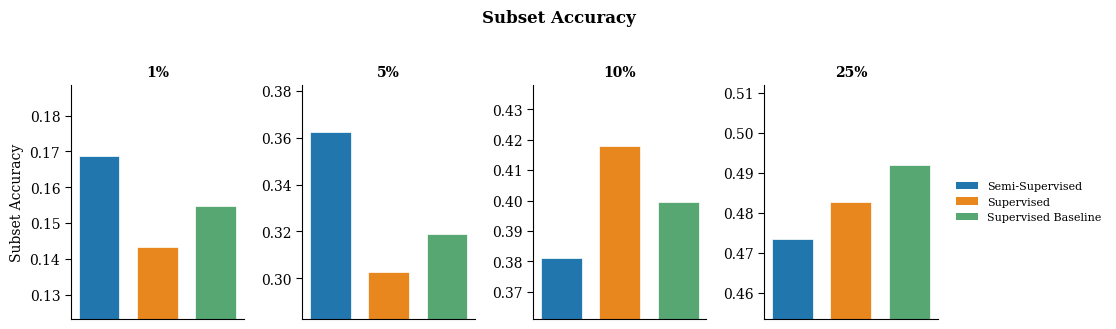

In [6]:
BAR_METRICS = METRICS_TO_PLOT  # same metrics as line plots

methods = list(EXPERIMENTS.keys())
n_methods = len(methods)
colors = [EXPERIMENTS[m]["color"] for m in methods]

for m in BAR_METRICS:
    data_per_frac = {}
    for frac in FRACTIONS:
        vals = []
        for label in methods:
            cfg = EXPERIMENTS[label]
            dfs = load_results(cfg["name"], cfg["mode"], frac)
            v = [df.loc[m["key"], "Metric Value"] for df in dfs if m["key"] in df.index]
            vals.append(np.mean(v) if v else np.nan)
        data_per_frac[frac] = vals

    active_fracs = [f for f in FRACTIONS if not all(np.isnan(v) for v in data_per_frac[f])]
    n_fracs = len(active_fracs)
    if n_fracs == 0:
        continue

    fig, axes = plt.subplots(1, n_fracs, figsize=(2.2 * n_fracs + 2.5, 3.2), sharey=False)
    if n_fracs == 1:
        axes = [axes]

    for i, frac in enumerate(active_fracs):
        ax = axes[i]
        vals = data_per_frac[frac]
        x = np.arange(n_methods)
        valid = [not np.isnan(v) for v in vals]

        ax.bar(
            [x[j] for j in range(n_methods) if valid[j]],
            [vals[j] for j in range(n_methods) if valid[j]],
            color=[colors[j] for j in range(n_methods) if valid[j]],
            edgecolor="white", linewidth=0.5, width=0.7,
        )

        valid_vals = [v for v in vals if not np.isnan(v)]
        if valid_vals:
            vmin, vmax = min(valid_vals), max(valid_vals)
            pad = max((vmax - vmin) * 0.2, 0.02)
            ax.set_ylim(max(0, vmin - pad), vmax + pad)

        ax.set_xticks([])
        ax.set_title(f"{int(frac*100)}%", fontsize=10)
        if i == 0:
            ax.set_ylabel(m["title"], fontsize=10)

    axes[-1].legend(
        [plt.Rectangle((0,0),1,1, fc=c) for c in colors],
        methods, frameon=True, edgecolor="none", facecolor="white",
        fontsize=8, loc="center left", bbox_to_anchor=(1.05, 0.5),
    )

    fig.suptitle(m["title"], fontsize=12, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()